In [5]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [20]:
# Import data
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\data\processed\CDC.csv', parse_dates=['obs_date'])

# Rename 'obs_date' to 'date' and set it as the index
data.rename(columns={'obs_date': 'date'}, inplace=True)
data.set_index('date', inplace=True)

# Display the first 10 rows
data.head(10)

,indicator,API_UserName,OpDiv,observations,curr_date
date,,,,,
2025-01-01,146.71.50.198,818860012482918321,CDC,1,2025-01-01
2025-01-01,149.36.49.225,818860012482918321,CDC,28,2025-01-01
2025-01-01,162.142.125.242,818860012482918321,CDC,3,2025-01-01
2025-01-01,162.142.125.247,818860012482918321,CDC,2,2025-01-01
2025-01-01,185.230.63.171,818860012482918321,CDC,6,2025-01-01
2025-01-01,23.26.221.12,818860012482918321,CDC,49,2025-01-01
2025-01-01,23.26.221.2,818860012482918321,CDC,51,2025-01-01
2025-01-01,23.26.221.4,818860012482918321,CDC,36,2025-01-01
2025-01-01,34.160.111.145,818860012482918321,CDC,4,2025-01-01


In [26]:
data.head()

,indicator,API_UserName,OpDiv,observations,curr_date
date,,,,,
2025-01-01,146.71.50.198,818860012482918321,CDC,1,2025-01-01
2025-01-01,149.36.49.225,818860012482918321,CDC,28,2025-01-01
2025-01-01,162.142.125.242,818860012482918321,CDC,3,2025-01-01
2025-01-01,162.142.125.247,818860012482918321,CDC,2,2025-01-01
2025-01-01,185.230.63.171,818860012482918321,CDC,6,2025-01-01


In [36]:
unique_indicators_count = data['indicator'].nunique()
print(f"Number of unique indicators: {unique_indicators_count}")

Number of unique indicators: 162


In [ ]:
# Group by 'indicator' and count occurrences over time
ip_grouped = data.groupby('indicator').resample('D').size().unstack(fill_value=0)

# Display the first 10 rows of the grouped data
ip_grouped.head(10)

date,2025-01-01,2025-01-02,2025-01-03,2025-01-04,2025-01-05,2025-01-06,2025-01-07,2025-01-08,2025-01-09,2025-01-10,...,2025-04-05,2025-04-06,2025-04-07,2025-04-08,2025-04-09,2025-04-10,2025-04-11,2025-04-12,2025-04-13,2025-04-14
indicator,,,,,,,,,,,,,,,,,,,,,
102.129.153.158,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102.129.153.43,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102.129.153.71,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102.165.16.161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
104.160.6.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
104.18.32.191,0,0,1,0,0,1,0,1,0,0,...,0,0,0,0,2,2,0,0,0,0
104.21.3.76,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
104.21.47.124,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
104.21.48.1,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,1,1,1


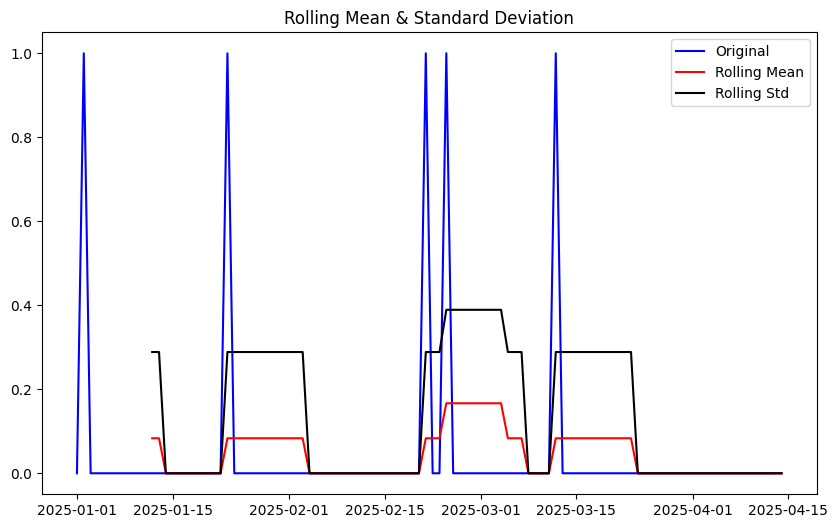

Results of Augmented Dickey-Fuller Test:
Test Statistic: -5.331679623678587
p-value: 4.706169761677296e-06
# Lags Used: 2
Number of Observations Used: 101
Critical Value (1%): -3.4968181663902103
Critical Value (5%): -2.8906107514600103
Critical Value (10%): -2.5822770483285953

Interpretation:
The time series is stationary. The null hypothesis of the ADF test (presence of a unit root) is rejected.


In [37]:
from statsmodels.tsa.stattools import adfuller

def visualize_stationarity(series):
	"""
	Visualize stationarity of a time series using rolling statistics and ADF test.
	"""
	rolling_mean = series.rolling(window=12).mean()
	rolling_std = series.rolling(window=12).std()

	# Plot rolling statistics
	plt.figure(figsize=(10, 6))
	plt.plot(series, label='Original', color='blue')
	plt.plot(rolling_mean, label='Rolling Mean', color='red')
	plt.plot(rolling_std, label='Rolling Std', color='black')
	plt.legend(loc='best')
	plt.title('Rolling Mean & Standard Deviation')
	plt.show()

	# Perform Augmented Dickey-Fuller test
	print('Results of Augmented Dickey-Fuller Test:')
	adf_test = adfuller(series.dropna())
	adf_results = {
		'Test Statistic': adf_test[0],
		'p-value': adf_test[1],
		'# Lags Used': adf_test[2],
		'Number of Observations Used': adf_test[3]
	}
	for key, value in adf_test[4].items():
		adf_results[f'Critical Value ({key})'] = value
	for key, value in adf_results.items():
		print(f'{key}: {value}')

	# Interpretation of results
	print("\nInterpretation:")
	if adf_results['p-value'] < 0.05 and adf_results['Test Statistic'] < adf_results['Critical Value (5%)']:
		print("The time series is stationary. The null hypothesis of the ADF test (presence of a unit root) is rejected.")
	else:
		print("The time series is not stationary. The null hypothesis of the ADF test (presence of a unit root) cannot be rejected.")

# Call the function on a specific row of ip_grouped
visualize_stationarity(ip_grouped.loc['102.129.153.71'])

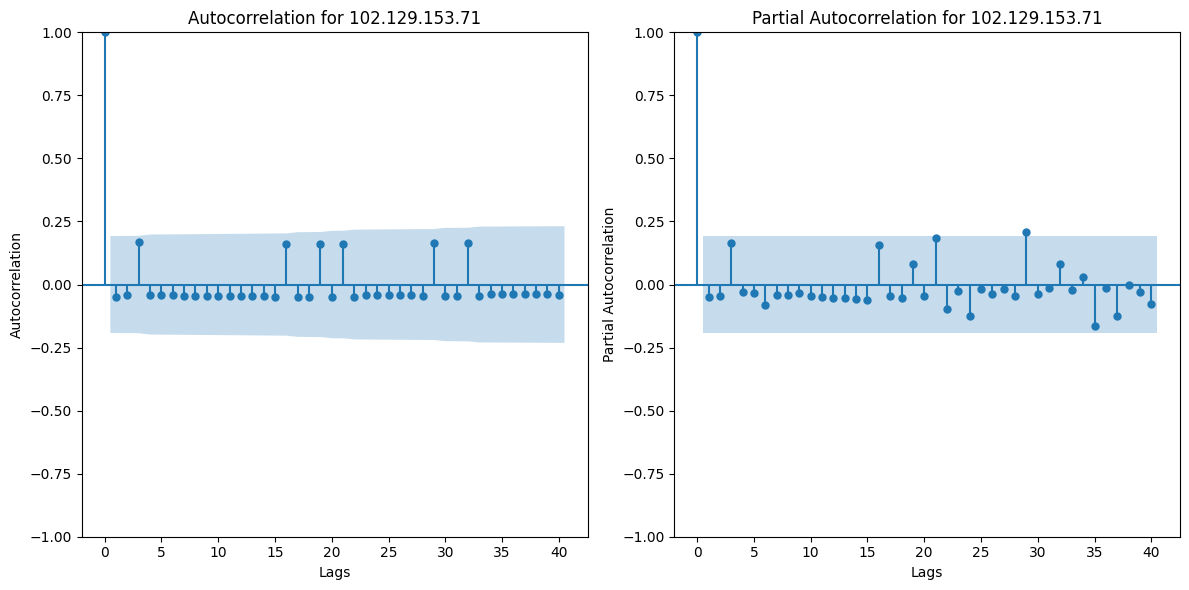

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create autocorrelation and partial autocorrelation plots for '102.129.153.71'
plt.figure(figsize=(12, 6))

# Autocorrelation plot
plt.subplot(1, 2, 1)
plot_acf(ip_grouped.loc['102.129.153.71'], lags=40, ax=plt.gca())
plt.title('Autocorrelation for 102.129.153.71')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')

# Partial autocorrelation plot
plt.subplot(1, 2, 2)
plot_pacf(ip_grouped.loc['102.129.153.71'], lags=40, ax=plt.gca(), method='ywm')
plt.title('Partial Autocorrelation for 102.129.153.71')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

These plots are essential for determining the parameters p (AR order) and q (MA order) in ARIMA models.

The **Autocorrelation Function (ACF)** plot and **Partial Autocorrelation Function (PACF)** plot are used to determine the order values for ARIMA models:

1. **Autocorrelation Function (ACF)**:
    - Helps determine the **MA (q)** (Moving Average) order.
    - Look for the lag at which the ACF plot cuts off (drops to near zero) or significantly decreases.

2. **Partial Autocorrelation Function (PACF)**:
    - Helps determine the **AR (p)** (Auto-Regressive) order.
    - Look for the lag at which the PACF plot cuts off (drops to near zero) or significantly decreases.

The **d (differencing order)** is determined separately by checking the stationarity of the time series (e.g., using the Augmented Dickey-Fuller test).


In [59]:
# Split the data for '102.129.153.71' into training and testing sets
series = ip_grouped.loc['102.129.153.71']
train_size = int(len(series) * 0.8)  # Use 80% of the data for training
train = series.iloc[:train_size]
train = train.asfreq('D').fillna(0)  # or .ffill(), .bfill() based on context
test = series.iloc[train_size:]

# Display the sizes of the training and testing sets
print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

Training set size: 83
Testing set size: 21


In [60]:
from itertools import product

# Generate a list of possible (p, d, q) combinations
p = range(0, 8)  # AR terms
d = range(0, 2)  # Differencing terms
q = range(0, 8)  # MA terms
possible_orders = list(product(p, d, q))

# Evaluate each order and store the AIC values
order_aic = []
for order in possible_orders:
    try:
        model = ARIMA(train, order=order)
        fitted_model = model.fit()
        order_aic.append((order, fitted_model.aic))
    except Exception as e:
        continue

# Sort the orders by AIC value
order_aic.sort(key=lambda x: x[1])

# Select the 5 best orders
best_orders = order_aic[:5]
print("Top 5 ARIMA orders based on AIC:")
for order, aic in best_orders:
    print(f"Order: {order}, AIC: {aic}")

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as star

KeyboardInterrupt: 

In [71]:
# Fit the ARIMA model (p, d, q)
order = (3, 0, 3)
model = ARIMA(train, order=order)
fitted_model = model.fit()

# Forecast future values
forecast_steps = 7  # Number of steps to forecast
forecast = fitted_model.get_forecast(steps=forecast_steps)

# Extract forecasted values and confidence intervals
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Align forecast_values index with forecast_dates
forecast_dates = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_values.index = forecast_dates
confidence_intervals.index = forecast_dates

threshold = 0.5
predicted_appearance = forecast_values[forecast_values >= threshold]

# Display the forecasted values
print(forecast_values)

import plotly.graph_objects as go

# Create an interactive plot using Plotly
fig = go.Figure()

# Add historical data trace
fig.add_trace(go.Scatter(x=series.index, y=series, mode='lines', name='Actual Values', line=dict(color='blue')))

# Add forecasted values trace
fig.add_trace(go.Scatter(x=forecast_dates, y=forecast_values, mode='lines', name='Forecasted Values', line=dict(color='orange', dash='dash')))

# Add confidence interval as shaded area
fig.add_trace(go.Scatter(
    x=forecast_dates, 
    y=confidence_intervals.iloc[:, 0],  # Lower bound
    mode='lines', 
    line=dict(color='rgba(128, 128, 128, 0.5)', dash='dot'), 
    name='Lower Bound'
))
fig.add_trace(go.Scatter(
    x=forecast_dates, 
    y=confidence_intervals.iloc[:, 1],  # Upper bound
    mode='lines', 
    line=dict(color='rgba(128, 128, 128, 0.5)', dash='dot'), 
    name='Upper Bound'
))

# Update layout for better visualization
fig.update_layout(
    title='Interactive Forecast Plot with Confidence Intervals',
    xaxis_title='Date',
    yaxis_title='Threat Event Count',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white'
)

# Show the interactive plot
fig.show()


2025-04-15    0.061464
2025-04-16    0.055282
2025-04-17    0.052629
2025-04-18    0.064362
2025-04-19    0.062706
2025-04-20    0.061264
2025-04-21    0.060660
Freq: D, Name: predicted_mean, dtype: float64


In [70]:
print("Predicted Dates for IP appearance:")
print(predicted_appearance.index)


Predicted Dates for IP appearance:
DatetimeIndex(['2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18',
               '2025-04-19', '2025-04-20', '2025-04-21'],
              dtype='datetime64[ns]', freq='D')


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

series = ip_grouped.loc['102.129.153.71']
test = series.iloc[train_size:]

# Calculate evaluation metrics
mae = mean_absolute_error(test[:forecast_steps], forecast_values)
mse = mean_squared_error(test[:forecast_steps], forecast_values)
rmse = np.sqrt(mse)

metrics = {
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse
}

# Calculate thresholds dynamically
mean_value = test.mean()  # Mean of the target variable
std_dev = test.std()      # Standard deviation of the target variable
variance = test.var()     # Variance of the target variable

# Define thresholds based on data characteristics
baseline_mae = mean_absolute_error(test, [mean_value] * len(test))
mae_threshold = 0.9 * baseline_mae  # 10% improvement over the baseline
mse_threshold = variance          # MSE threshold as the variance of the target variable
rmse_threshold = std_dev          # RMSE threshold as the standard deviation

# Display the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print("\nThresholds:")
print(f"MAE Threshold: {mae_threshold}")
print(f"MSE Threshold: {mse_threshold}")
print(f"RMSE Threshold: {rmse_threshold}")

# Interpretation of the metrics
print("\nInterpretation:")
print(f"1. Mean Absolute Error (MAE): On average, the forecasted values deviate from the actual values by {mae:.2f} threat events.")
if mae < mae_threshold:
    print("   This is a good result, indicating low average deviation.")
else:
    print("   This is a bad result, indicating high average deviation.")

print(f"2. Mean Squared Error (MSE): The average squared difference between the forecasted and actual values is {mse:.2f}. This metric penalizes larger errors more heavily.")
if mse < mse_threshold:
    print("   This is a good result, indicating low squared errors.")
else:
    print("   This is a bad result, indicating high squared errors.")

print(f"3. Root Mean Squared Error (RMSE): The RMSE of {rmse:.2f} provides a measure of the average magnitude of the forecast errors, expressed in the same units as the data (threat events). Lower values indicate better model performance.")
if rmse < rmse_threshold:
    print("   This is a good result, indicating low forecast error magnitude.")
else:
    print("   This is a bad result, indicating high forecast error magnitude.")

Mean Absolute Error (MAE): 0.059766679424873285
Mean Squared Error (MSE): 0.0035873030109493872
Root Mean Squared Error (RMSE): 0.05989409829815778

Thresholds:
MAE Threshold: 0.0
MSE Threshold: 0.0
RMSE Threshold: 0.0

Interpretation:
1. Mean Absolute Error (MAE): On average, the forecasted values deviate from the actual values by 0.06 threat events.
   This is a bad result, indicating high average deviation.
2. Mean Squared Error (MSE): The average squared difference between the forecasted and actual values is 0.00. This metric penalizes larger errors more heavily.
   This is a bad result, indicating high squared errors.
3. Root Mean Squared Error (RMSE): The RMSE of 0.06 provides a measure of the average magnitude of the forecast errors, expressed in the same units as the data (threat events). Lower values indicate better model performance.
   This is a bad result, indicating high forecast error magnitude.


In [96]:
# Check if the new metrics are better than the best metrics in storage
if 'metrics_storage' not in locals():
    raise NameError("metrics_storage is not defined. Please define it before using this code.")

if 'add_metrics' not in locals():
    raise NameError("add_metrics is not defined. Please define it before using this code.")

# Initialize a flag to track if the new metrics are better
is_better = True

# Iterate through all stored metrics to compare
for stored_order, stored_metrics in metrics_storage.items():
    print(f"Comparing with stored metrics for order {stored_order}: {stored_metrics}")
    if not (mse < stored_metrics['MSE'] and mae < stored_metrics['MAE'] and rmse < stored_metrics['RMSE']):
        is_better = False
        break

# Save the new metrics only if they are better than all stored metrics
if is_better:
    add_metrics(metrics_storage, order, metrics)
    print("Metrics saved (better than all stored metrics).")
else:
    print("Metrics not saved as they are not better than the best stored metrics.")

Comparing with stored metrics for order (3, 3, 2): {'MAE': 20.9, 'MSE': 605.0333333333333, 'RMSE': 24.59742533952148}
Comparing with stored metrics for order (0, 1, 4): {'MAE': 11.505355191700327, 'MSE': 176.96911405471985, 'RMSE': 13.302973880103647}
Comparing with stored metrics for order (2, 0, 4): {'MAE': 11.32786998822572, 'MSE': 174.35982108898074, 'RMSE': 13.204537897593415}
Comparing with stored metrics for order (4, 0, 2): {'MAE': 11.243638755113006, 'MSE': 171.43563483399836, 'RMSE': 13.093343149631357}
Comparing with stored metrics for order (3, 0, 3): {'MAE': 11.128306751875092, 'MSE': 168.95395506818377, 'RMSE': 12.998228920440807}
Metrics not saved as they are not better than the best stored metrics.


In [97]:
metrics_df = pd.DataFrame.from_dict(metrics_storage, orient='index')

# Reset the index and ensure ARIMA_Order is retained as a column
metrics_df.index.name = 'ARIMA_Order'
metrics_df.reset_index(inplace=True)

# Ensure ARIMA_Order exists before splitting into p, d, q
if metrics_df is not None and not metrics_df.empty and 'ARIMA_Order' in metrics_df.columns:
    # Split ARIMA_Order into separate columns for p, d, q
    metrics_df[['p', 'd', 'q']] = pd.DataFrame(metrics_df['ARIMA_Order'].tolist(), index=metrics_df.index)
    
    # Drop the original ARIMA_Order column
    metrics_df = metrics_df.drop(columns=['ARIMA_Order'])

    # Reorder columns for better readability
    metrics_df = metrics_df[['p', 'd', 'q', 'MAE', 'MSE', 'RMSE']]

metrics_df.rename(columns={'level_0': 'p', 'level_1': 'd', 'level_2': 'q'}, inplace=True)
print(metrics_df)

   p  d  q        MAE         MSE       RMSE
0  3  3  2  20.900000  605.033333  24.597425
1  0  1  4  11.505355  176.969114  13.302974
2  2  0  4  11.327870  174.359821  13.204538
3  4  0  2  11.243639  171.435635  13.093343
4  3  0  3  11.128307  168.953955  12.998229


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.35 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2267.228, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2093.841, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2188.758, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2032.198, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2027.236, Time=0.03 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=2019.663, Time=0.03 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=2001.069, Time=0.05 sec


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed

 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.31 sec


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1951.283, Time=0.28 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1950.920, Time=0.19 sec


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=1953.047, Time=0.18 sec

Best model:  ARIMA(4,0,0)(0,0,0)[0] intercept
Total fit time: 2.097 seconds
Selected ARIMA order: (4, 0, 0)
2024-08-26    0.0
2024-08-27    0.0
2024-08-28    0.0
2024-08-29    0.0
2024-08-30    0.0
2024-08-31    0.0
2024-09-01    0.0
2024-09-02    0.0
2024-09-03    0.0
2024-09-04    0.0
2024-09-05    0.0
2024-09-06    0.0
2024-09-07    0.0
2024-09-08    0.0
2024-09-09    0.0
2024-09-10    0.0
2024-09-11    0.0
2024-09-12    0.0
2024-09-13    0.0
2024-09-14    0.0
2024-09-15    0.0
2024-09-16    0.0
2024-09-17    0.0
2024-09-18    0.0
2024-09-19    0.0
2024-09-20    0.0
2024-09-21    0.0
2024-09-22    0.0
2024-09-23    0.0
2024-09-24    0.0
Freq: D, Name: predicted_mean, dtype: float64


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



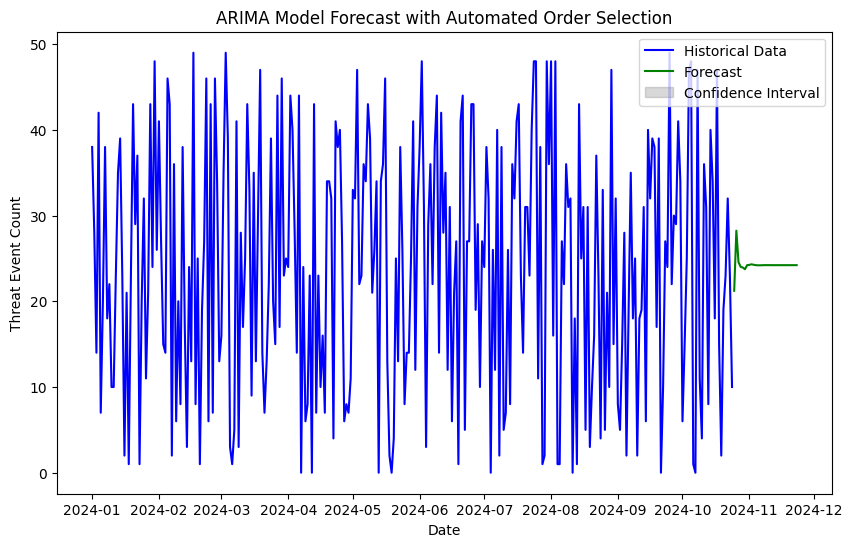

In [45]:
from pmdarima import auto_arima

# Automate the selection of ARIMA order
auto_model = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, trace=True)
order = auto_model.order
print(f"Selected ARIMA order: {order}")

# Refit the ARIMA model with the selected order
model = ARIMA(train, order=order)
fitted_model = model.fit()

# Forecast future values
auto_forecast = fitted_model.get_forecast(steps=forecast_steps)
auto_forecast_values = auto_forecast.predicted_mean
auto_confidence_intervals = auto_forecast.conf_int()

# Display the forecasted values
print(forecast_values)

# Visualize the forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Threat_Event_Count'], label='Historical Data', color='blue')

# Ensure data.index is a DatetimeIndex
if not isinstance(data.index, pd.DatetimeIndex):
    data.index = pd.to_datetime(data.index)

# Generate forecasted dates
forecast_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

plt.plot(forecast_dates, auto_forecast_values, label='Forecast', color='green')
plt.fill_between(forecast_dates, 
                 confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='gray', alpha=0.3, label='Confidence Interval')
plt.legend()
plt.title('ARIMA Model Forecast with Automated Order Selection')
plt.xlabel('Date')
plt.ylabel('Threat Event Count')
plt.show()

In [46]:
test = data.iloc[train_size:]

auto_mae = mean_absolute_error(test['Threat_Event_Count'][:forecast_steps], auto_forecast_values)
auto_mse = mean_squared_error(test['Threat_Event_Count'][:forecast_steps], auto_forecast_values)
auto_rmse = np.sqrt(mse)

# Display the evaluation metrics
print(f"Mean Absolute Error (MAE): {auto_mae}")
print(f"Mean Squared Error (MSE): {auto_mse}")
print(f"Root Mean Squared Error (RMSE): {auto_rmse}")
print("\nThresholds:")
print(f"MAE Threshold: {mae_threshold}")
print(f"MSE Threshold: {mse_threshold}")
print(f"RMSE Threshold: {rmse_threshold}")

Mean Absolute Error (MAE): 11.538524632400927
Mean Squared Error (MSE): 177.90851816682326
Root Mean Squared Error (RMSE): 24.59742533952148

Thresholds:
MAE Threshold: 10.98
MSE Threshold: 208.09152542372877
RMSE Threshold: 14.425377826030372
